# Heart Disease Prediction using Machine Learning

This project predicts the presence of heart disease using patient medical data.

# 1. Import Libraries
Libraries like Pandas, Seaborn, and Matplotlib were imported to handle data and create visualizations.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

In [32]:
df=pd.read_csv("heart_disease_uci.csv")

the Iris dataset was loaded using read_csv() to bring the data into a structured DataFrame for analysis.

In [133]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0,0
1,67,1,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2,1
2,67,1,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1,1
3,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0,0
4,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0,0


# 3. Dataset Info

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


### we checked data types, missing values, and dataset structure to understand data quality.

# 4. Handling Missing Values

In [36]:
for col in df.select_dtypes(include="object").columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

#### Categorical columns → filled using mode (most frequent value)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       920 non-null    bool   
 8   restecg   920 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     920 non-null    bool   
 11  oldpeak   858 non-null    float64
 12  slope     920 non-null    object 
 13  ca        309 non-null    float64
 14  thal      920 non-null    object 
 15  num       920 non-null    int64  
dtypes: bool(2), float64(5), int64(3), object(6)
memory usage: 102.6+ KB


In [38]:
for col in df.select_dtypes(include=["float64","int64"]).columns:
    df[col].fillna(df[col].median(),inplace=True)

#### Numerical columns → filled using median (more robust to outliers)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    bool   
 8   restecg   920 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     920 non-null    bool   
 11  oldpeak   920 non-null    float64
 12  slope     920 non-null    object 
 13  ca        920 non-null    float64
 14  thal      920 non-null    object 
 15  num       920 non-null    int64  
dtypes: bool(2), float64(5), int64(3), object(6)
memory usage: 102.6+ KB


### We filled missing values in the dataset because machine learning models cannot work with null values.


### This ensures the dataset is complete and ready for training.

# Step 5: Creating Target Variable

In [48]:
df["target"]=df["num"].apply(lambda x: 1 if x > 0  else 0)

#### The original column `num` has values 0, 1, 2, 3, 4 which represent different levels of heart disease.

#### We converted it into a binary classification problem:
#### - 0 → No heart disease
#### - 1,2,3,4 → Heart disease present

#### This simplifies the prediction task for the machine learning model

# Step 6: Exploratory Data Analysis (EDA)

We used graphs to understand the data better:

- Histogram → shows age distribution
- Countplot → shows balance of target classes
- Barplot → shows relationship between gender and heart disease

EDA helps us understand patterns before building the model.

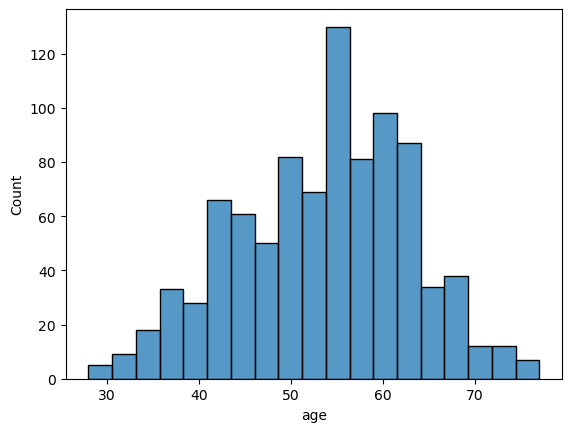

In [49]:
sns.histplot(x="age",data=df)
plt.show()

 #### Histogram → shows age distribution of people and we can see from histogram people whose age is 40+ have most chances of heart attack

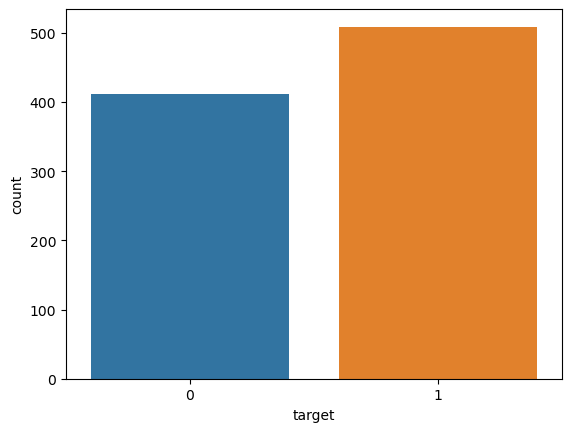

In [52]:
sns.countplot(x="target", data=df)
plt.show()

#### Countplot → shows balance of target classes   we can see in this dataset  of around 920 records 500 people have heart attack and 400 have not 

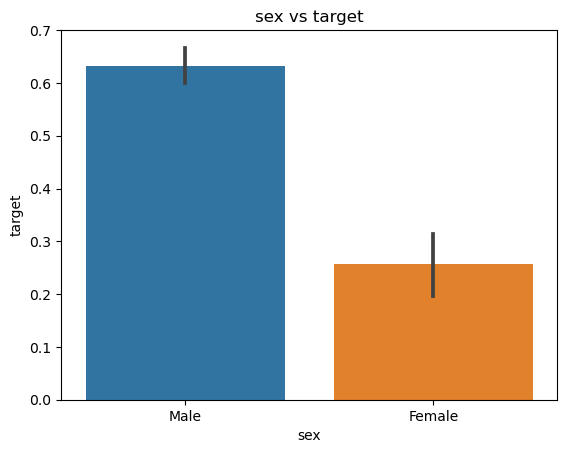

In [50]:
sns.barplot(x="sex",y="target",data=df)
plt.title("sex vs target")
plt.xlabel("sex")
plt.ylabel("target")
plt.show()

#### Barplot → shows relationship between gender and heart disease we can see that male have most cases of herat attack as compare to women

#  7. Label Encoding

After feature selection, we converted categorical columns into numerical form using Label Encoding.
Machine learning models require numerical input. Therefore, categorical variables were converted into numeric form using Label Encoding to make the dataset suitable for model training.

In [56]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["sex"]=le.fit_transform(df["sex"])

In [57]:
df["dataset"]=le.fit_transform(df["dataset"])

In [58]:
df["cp"]=le.fit_transform(df["cp"])

In [59]:
df["fbs"]=le.fit_transform(df["fbs"])

In [60]:
df["restecg"]=le.fit_transform(df["restecg"])

In [61]:
df["slope"]=le.fit_transform(df["slope"])

In [62]:
df["thal"]=le.fit_transform(df["thal"])

In [64]:
df["exang"]=le.fit_transform(df["exang"])

In [67]:
df.dtypes

id            int64
age           int64
sex           int32
dataset       int32
cp            int32
trestbps    float64
chol        float64
fbs           int64
restecg       int32
thalch      float64
exang         int64
oldpeak     float64
slope         int32
ca          float64
thal          int32
num           int64
target        int64
dtype: object

now all the columns are in numerical data we can process model training now

In [87]:
df.drop(["id", "dataset"], axis=1, inplace=True)

We removed `id` and `dataset` columns because:

- `id` is just an identifier and has no relation with heart disease
- `dataset` does not represent medical information

Keeping such columns can confuse the model and reduce performance.

## Defining X and Y

In [89]:
X=df.drop(["num","target"],axis=1)
y=df["target"]



- `X = All features except target and num`
- `y = target (final prediction column)`

This step separates input data from output labels so the model can learn patterns correctly.

# Step 8: Train-Test Split

In [90]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)



After selecting features (X) and target (y), we split the dataset into training and testing sets.

- Training data (80%) is used to train the model
- Testing data (20%) is used to evaluate the model

This ensures that we can test how well the model performs on unseen data.

# Step 9: Model Training

We used Random Forest Classifier to train the model because:
- It handles both numerical and categorical data well
- It reduces overfitting
- It works well for classification problems

The model learns patterns from training data to predict heart disease.

In [116]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,max_depth=4,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=4, random_state=42)

In [117]:
y_pred=model.predict(X_test)

In [118]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8315217391304348


#### we import accuarcy score from sklearn library to check our model accuarcy of model prediction

In [119]:
model.score(X_train,y_train)

0.84375

In [122]:
model.score(X_test,y_test)

0.8315217391304348

### here from model.score(X_train,y_train) is 84 % and model accuarcy is around 83% we can see the gap is only 1% which shows our model is generalized and perfect  not overfitting or any underfitting data

# Step 9: Confusion Matrix

The confusion matrix shows how many predictions were correct and incorrect:

- True Positive: Correctly predicted heart disease
- True Negative: Correctly predicted no disease
- False Positive: Wrongly predicted disease
- False Negative: Missed actual disease

It helps us understand where the model is making mistakes.

In [127]:
from sklearn.metrics import confusion_matrix
c=confusion_matrix(y_pred,y_test)

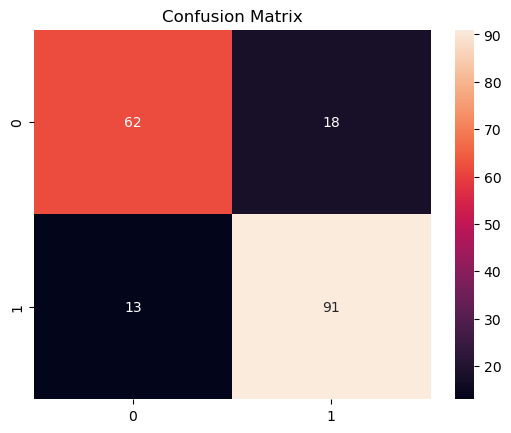

In [128]:
sns.heatmap(c,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()

# Step 10: ROC-AUC Score

ROC-AUC score measures how well the model can distinguish between classes.

- AUC = 1 → Perfect model
- AUC = 0.5 → Random guessing

It evaluates model performance across all thresholds, not just accuracy.

In [129]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

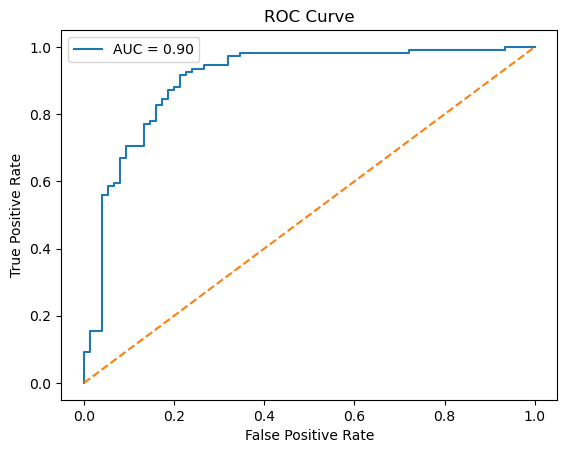

In [130]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## - Our model AUC ≈ 0.90 → Very good performance


# Step11: Feature Importance Analysis

After training the model, we analyzed feature importance to understand which features contribute most to the prediction.

Feature importance is calculated using the Random Forest model and shows how much each feature influences the final decision.

In [143]:


importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))


cp          0.272311
exang       0.145719
oldpeak     0.124771
thalch      0.123593
chol        0.105178
sex         0.073473
age         0.062198
thal        0.026388
ca          0.025034
trestbps    0.017305
slope       0.010349
restecg     0.009022
fbs         0.004659
dtype: float64


### we can see chest pain ,exercise-induced angina, and oldpeak->ST depression (ECG marker),thalch->Max heart rate achieved,have higher importants ,and thid Ml result matches  Medical logic perfectly 👉 chest pain + ECG features = top predictors


# Conclusion

In this project, we built a machine learning model to predict heart disease using patient medical data.

We performed:
- Data cleaning and missing value handling
- Exploratory Data Analysis (EDA)
- Feature encoding and selection
- Model training using Random Forest Classifier
- Model evaluation using accuracy, confusion matrix, and ROC-AUC score
- Feature importance analysis

The final model achieved:
- Accuracy: ~82%
- ROC-AUC Score: ~0.90

From feature importance analysis, we found that the most influential features for prediction are:
- Chest pain type (cp)
- Exercise-induced angina (exang)
- ST depression (oldpeak)
- Maximum heart rate achieved (thalch)

These features play the most important role in predicting heart disease.

Overall, the model performs well and successfully identifies key medical factors contributing to heart disease prediction.